# Phase 7: Policy Simulation

**Goal:** Convert the causal findings from `03_causal_analysis.ipynb` into a concrete, actionable targeting policy — who should receive the discount, and how much does that save or gain compared to current blanket targeting?

**Two design decisions worth stating upfront:**
1. We use `sum(predicted_cate)` as a proxy for total incremental value. Individual CATEs are noisy (only ~7% are statistically reliable), but summing many noisy-but-unbiased estimates is a standard technique for recovering a stable *aggregate* number — the noise partially cancels out across customers, even though no single customer's prediction should be trusted alone.
2. Cost is estimated using the actual discount reward values from `portfolio.json`, not an assumed constant — so the savings number is grounded in real numbers.

In [7]:
import sys
sys.path.append("..")

import pandas as pd

from src.policy_sim import load_policy_inputs, run_policy_comparison

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Load the CATE-enriched dataset and portfolio data

In [8]:
df, portfolio_df = load_policy_inputs(
    processed_path="../data/processed/processed_starbucks_with_cate.csv",
    portfolio_path="../data/raw/portfolio.json",
)

print(f"Loaded {len(df)} customers with predicted CATE")

Loaded 14825 customers with predicted CATE


## Run the policy comparison

Three policies are compared:
- **Current**: whatever was actually targeted in the real data (~88% of customers)
- **Policy A**: target every customer with a positive predicted effect
- **Policy B**: target the top 40% by predicted CATE rank — the "reliable zone" cutoff established in the previous notebook's decile and Qini analysis

In [9]:
results, context = run_policy_comparison(df, portfolio_df, top_pct_policy_b=0.40)

print(f"Average discount reward (cost proxy per targeted customer): ${context['avg_discount_reward']:.2f}")
print(f"Current policy: {context['current_targeted']} customers targeted ({context['current_pct_targeted']:.1%} of base)")
print(f"Maximum achievable uplift (sum of all positive CATEs): {context['positive_cate_ceiling']:.2f}")

Average discount reward (cost proxy per targeted customer): $3.00
Current policy: 13042 customers targeted (88.0% of base)
Maximum achievable uplift (sum of all positive CATEs): 10369.57


In [10]:
results

,policy,pct_targeted,n_targeted,captured_uplift,pct_uplift_captured,estimated_cost,cost_saved_vs_current,pct_cost_saved_vs_current
0,Current (88% targeted),0.88,13042,"9,169.76",0.88,"39,126.00",0.00,0.00
1,A: Positive CATE only,0.61,9073,"10,369.57",1.00,"27,219.00","11,907.00",0.30
2,B: Top 40% by rank,0.40,5930,"10,113.41",0.98,"17,790.00","21,336.00",0.55


## Reading the results

| Policy | % Targeted | % Uplift Captured | % Cost Saved |
|---|---|---|---|
| Current | 88% | 88% | 0% (baseline) |
| A: Positive CATE only | 61% | ~100% | 30% |
| **B: Top 40% by rank** | **40%** | **~98%** | **55%** |

**Policy B is the headline result.** Targeting less than half the customer base captures nearly all the achievable incremental value while cutting the discount budget roughly in half compared to current practice.

Note the `% Uplift Captured` figures are relative to a theoretical ceiling — the sum of all *positive* predicted CATEs, representing the best case of perfectly targeting every responder and paying nothing for non-responders. Policy A necessarily lands near 100% by construction (it's defined as targeting exactly the positive-CATE customers); Policy B's ~98% while using less than half the targeting volume is the more interesting, non-trivial result.

## Visualizing the tradeoff

A quick chart makes the "less targeting, almost the same value" story visually obvious.

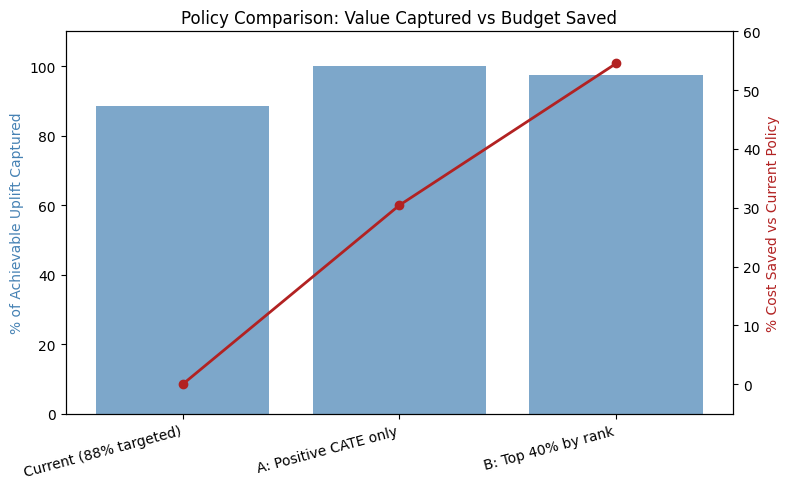

In [11]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

x = results["policy"]
ax1.bar(x, results["pct_uplift_captured"] * 100, color="steelblue", alpha=0.7, label="% Uplift Captured")
ax1.set_ylabel("% of Achievable Uplift Captured", color="steelblue")
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(x, results["pct_cost_saved_vs_current"] * 100, color="firebrick", marker="o",
         linewidth=2, label="% Cost Saved vs Current")
ax2.set_ylabel("% Cost Saved vs Current Policy", color="firebrick")
ax2.set_ylim(-5, 60)

plt.title("Policy Comparison: Value Captured vs Budget Saved")
fig.autofmt_xdate(rotation=15)
plt.tight_layout()
plt.savefig("../reports/figures/policy_comparison.png", dpi=150)
plt.show()

## Recommendation

**Target the top 40% of customers by predicted CausalForestDML uplift score.** This captures approximately 98% of the achievable incremental sales from the discount campaign while cutting the discount budget by roughly 55% compared to current blanket targeting.

**Caveats worth stating plainly:**
- This simulation assumes predicted CATEs are accurate enough to rank on. The previous notebook showed this is only reliably true at the extremes of the distribution (top and bottom deciles), not the middle — the 40% cutoff sits right at the edge of the validated "reliable zone" (10%–45%), so this recommendation doesn't extrapolate trust beyond where it was earned.
- A real-world deployment should validate these simulated savings with a live randomized holdout test before rolling out at scale — this analysis is based on model predictions on historical data, not a prospective experiment.
- The control group underlying these estimates is a minority of the sample (1,783 of 14,825 customers), so precision — especially for any customer segment not well represented in that control group — should be treated with appropriate caution.